# A/B Test: Checkout Free Shipping Banner
## Stage 3a: Exploratory Data Analysis

**Project:** dbt-portfolio-498511 &nbsp;·&nbsp; **Dataset:** dbt_analytics &nbsp;·&nbsp; **Table:** fct_experiment_results

This notebook loads the simulated experiment results, checks data quality, verifies the variant split is balanced, and visualises the key metrics before statistical testing in the next notebook.

In [1]:
!pip install google-cloud-bigquery google-cloud-bigquery-storage db-dtypes

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from google.cloud import bigquery

BACKGROUND = '#DDDCD6'
TEAL       = '#0D9488'   # control variant
PURPLE     = '#6B21A8'   # treatment variant

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
})

## 1. Load the experiment results

In [3]:
client = bigquery.Client(project='dbt-portfolio-498511')

query = '''
    select
        order_id,
        user_id,
        variant,
        order_status,
        order_created_at,
        order_value,
        item_count,
        is_completed,
        is_returned
    from `dbt-portfolio-498511.dbt_analytics.fct_experiment_results`
'''

df = client.query(query).to_dataframe()
print(f'Loaded {len(df):,} rows')
df.head()

Loaded 463 rows


,order_id,user_id,variant,order_status,order_created_at,order_value,item_count,is_completed,is_returned
0,39023,31305,control,Complete,2024-01-28 11:28:29+00:00,38.900000,2,1,0
1,90419,72705,control,Complete,2024-01-01 04:35:32+00:00,59.950001,1,1,0
2,990,808,control,Complete,2024-01-06 23:58:56+00:00,256.989998,3,1,0
3,52457,42147,control,Complete,2024-01-09 23:13:21+00:00,27.400000,1,1,0
4,61402,49359,control,Complete,2024-01-08 05:15:47+00:00,97.300003,1,1,0


## 2. Data quality check

In [4]:
print(f'Shape: {df.shape}')
print(f'\nColumn types:')
print(df.dtypes)
print(f'\nNull counts:')
print(df.isnull().sum())

Shape: (463, 9)

Column types:
order_id                          Int64
user_id                           Int64
variant                          object
order_status                     object
order_created_at    datetime64[us, UTC]
order_value                     float64
item_count                        Int64
is_completed                      Int64
is_returned                       Int64
dtype: object

Null counts:
order_id            0
user_id             0
variant             0
order_status        0
order_created_at    0
order_value         0
item_count          0
is_completed        0
is_returned         0
dtype: int64


## 3. Variant balance

The hash-based assignment should produce a roughly 50/50 split.
A significant imbalance here would indicate a problem with the assignment logic.

In [5]:
balance = df.groupby('variant').agg(
    orders  = ('order_id', 'count'),
    users   = ('user_id', 'nunique'),
).reset_index()
balance['pct_orders'] = (balance['orders'] / balance['orders'].sum() * 100).round(1)
print(balance.to_string(index=False))

  variant  orders  users  pct_orders
  control     235    234        50.8
treatment     228    226        49.2


## 4. Summary statistics by variant

These are the raw figures before any statistical testing.
AOV and conversion rate are the two metrics the analysis focuses on.

In [6]:
summary = df.groupby('variant').agg(
    orders             = ('order_id',    'count'),
    avg_order_value    = ('order_value', 'mean'),
    median_order_value = ('order_value', 'median'),
    std_order_value    = ('order_value', 'std'),
    conversion_rate    = ('is_completed', 'mean'),
    return_rate        = ('is_returned',  'mean'),
).reset_index()

summary['avg_order_value']    = summary['avg_order_value'].map('£{:.2f}'.format)
summary['median_order_value'] = summary['median_order_value'].map('£{:.2f}'.format)
summary['std_order_value']    = summary['std_order_value'].map('£{:.2f}'.format)
summary['conversion_rate']    = summary['conversion_rate'].map('{:.1%}'.format)
summary['return_rate']        = summary['return_rate'].map('{:.1%}'.format)

print(summary.to_string(index=False))

  variant  orders avg_order_value median_order_value std_order_value conversion_rate return_rate
  control     235          £88.41             £58.00         £104.59           73.2%       26.8%
treatment     228          £87.92             £49.97          £94.56           74.1%       25.9%


## 5. Distribution plots

Visualise order value distributions and conversion rates per variant.
Teal = control, purple = treatment.

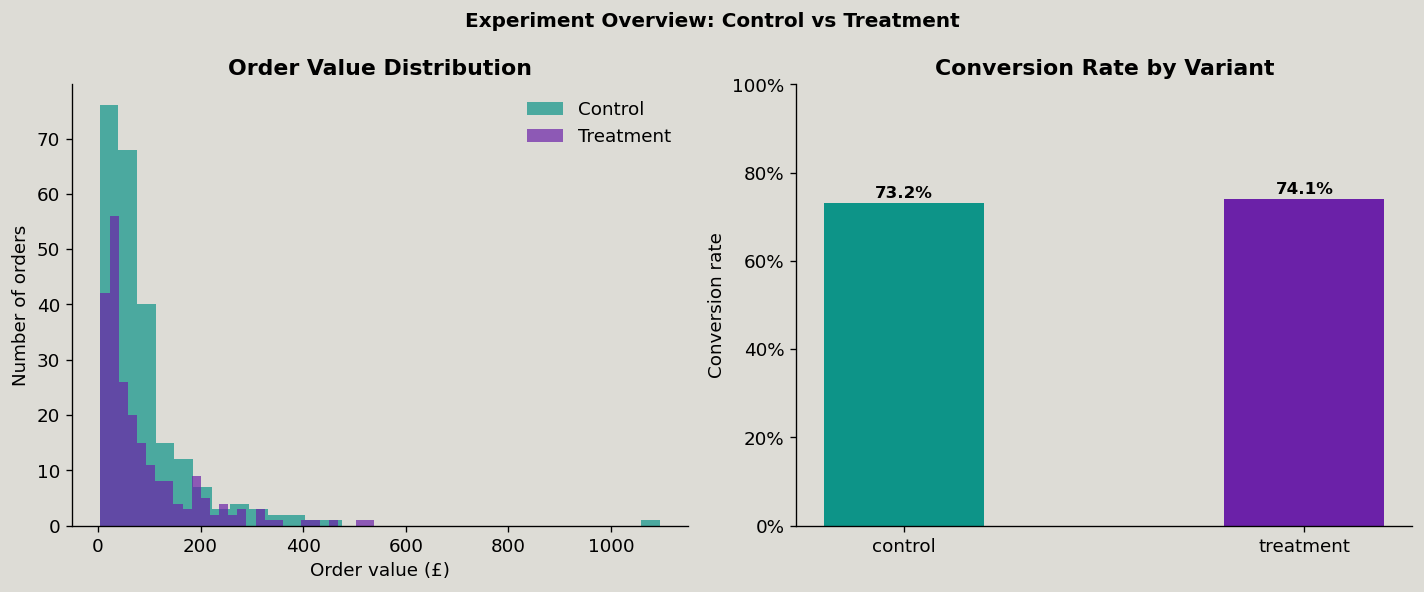

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.set_facecolor(BACKGROUND)

# Order value distribution
for variant, color in [('control', TEAL), ('treatment', PURPLE)]:
    data = df[df['variant'] == variant]['order_value']
    axes[0].hist(data, bins=30, alpha=0.7, color=color,
                 label=variant.title(), edgecolor='none')

axes[0].set_xlabel('Order value (£)')
axes[0].set_ylabel('Number of orders')
axes[0].set_facecolor(BACKGROUND)
axes[0].legend(framealpha=0)
axes[0].set_title('Order Value Distribution', fontweight='bold')

# Conversion rate by variant
variants   = ['control', 'treatment']
conv_rates = [df[df['variant'] == v]['is_completed'].mean() for v in variants]
bars = axes[1].bar(variants, conv_rates, color=[TEAL, PURPLE], width=0.4)

axes[1].set_ylabel('Conversion rate')
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
axes[1].set_facecolor(BACKGROUND)
axes[1].set_title('Conversion Rate by Variant', fontweight='bold')

for bar, rate in zip(bars, conv_rates):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.01,
                 f'{rate:.1%}', ha='center', fontsize=10, fontweight='bold')

fig.suptitle('Experiment Overview: Control vs Treatment', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/eda_overview.png', facecolor=BACKGROUND, bbox_inches='tight')
plt.show()

C:\Users\mahan\AppData\Local\Temp\ipykernel_20804\3693226450.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


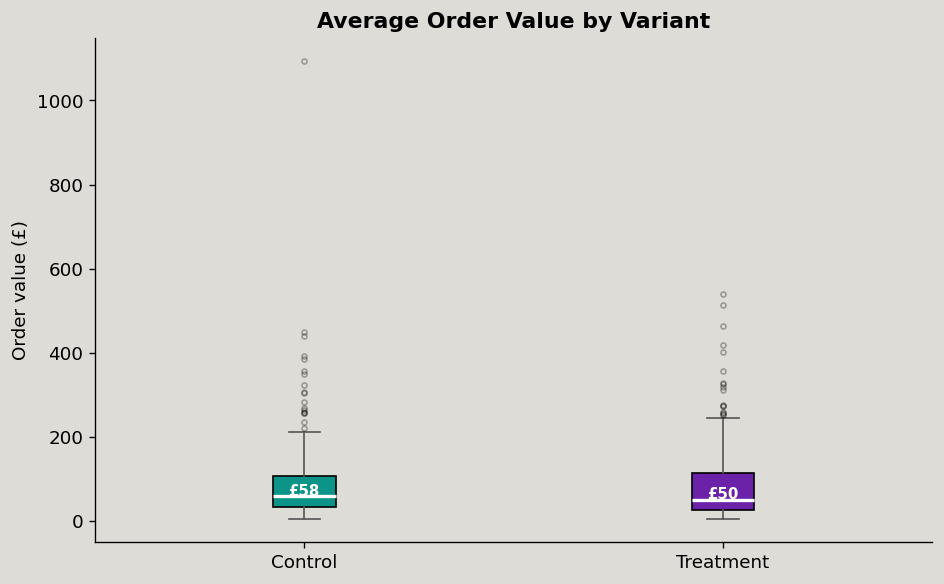

In [8]:
# AOV side by side box plot
fig, ax = plt.subplots(figsize=(8, 5))
fig.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

control_values   = df[df['variant'] == 'control']['order_value']
treatment_values = df[df['variant'] == 'treatment']['order_value']

bp = ax.boxplot(
    [control_values, treatment_values],
    labels=['Control', 'Treatment'],
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(color='#555555'),
    capprops=dict(color='#555555'),
    flierprops=dict(marker='o', markersize=3, alpha=0.3, color='#555555'),
)

for patch, color in zip(bp['boxes'], [TEAL, PURPLE]):
    patch.set_facecolor(color)

ax.set_ylabel('Order value (£)')
ax.set_title('Average Order Value by Variant', fontweight='bold')

# Annotate medians
for i, values in enumerate([control_values, treatment_values], 1):
    med = values.median()
    ax.text(i, med + 2, f'£{med:.0f}', ha='center', fontsize=9,
            color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/eda_aov_boxplot.png', facecolor=BACKGROUND, bbox_inches='tight')
plt.show()

## 6. Initial observations

Fill these in after running the notebook with real data:

- **Variant balance:** Variant balance: 50.8 / 49.2, well balanced
- **AOV difference (raw):** AOV difference (raw): Control £88.41 vs Treatment £87.92, a difference of £0.49
- **Conversion rate difference (raw):** Conversion rate difference (raw): Control 73.2% vs Treatment 74.1%, a difference of 0.9 percentage points
- **Return rate difference (raw):** Return rate difference (raw): Control 26.8% vs Treatment 25.9%, similar across both variants
- **Any data quality issues spotted:** Data quality: zero nulls, 463 rows, all columns correctly typed

Statistical significance is assessed in the next notebook: `03_statistical_analysis.ipynb`.